In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import re

In [21]:
data = pd.read_excel("Final Clinical outcome data 14.02.25.xlsx", sheet_name= "Clinical Data ML")

In [22]:
data.shape

(599, 319)

## Data Tranformation

# Site of Infections

In [23]:

# Get infection site column names
infection_site_cols = [col for col in data.columns if col.startswith('infect_site')]

# More efficient method using apply
def get_infection_sites(row):
    yes_sites = [col.replace('infect_site_', '').replace('___', '') for col in infection_site_cols if row[col] == 'Yes']
    return pd.Series(yes_sites, index=[f'Infection_Site_{i+1}' for i in range(len(yes_sites))])

new_data = data.apply(get_infection_sites, axis=1)
data = pd.concat([data, new_data], axis=1)

print(data)

    name_of_rrh   age     sex hosp_48hrs infect_site_Brain infect_site_Lungs  \
0          Arua   6.0    Male        Yes               Yes                No   
1          Arua  13.0    Male        Yes                No               Yes   
2          Arua  11.0    Male        Yes                No                No   
3          Arua  18.0    Male        Yes                No                No   
4          Arua  17.0  Female        Yes                No                No   
..          ...   ...     ...        ...               ...               ...   
594      Soroti   2.0  Female        Yes                No                No   
595      Soroti  27.0  Female        Yes                No                No   
596      Soroti  20.0  Female        Yes                No                No   
597      Soroti  24.0  Female        Yes                No                No   
598      Soroti   2.0  Female        Yes                No               Yes   

    infect_site_Gastro_intestil_tract i

[Text(0, 0, '84'),
 Text(0, 0, '98'),
 Text(0, 0, '90'),
 Text(0, 0, '55'),
 Text(0, 0, '126'),
 Text(0, 0, '3'),
 Text(0, 0, '71'),
 Text(0, 0, '32'),
 Text(0, 0, '90'),
 Text(0, 0, '13'),
 Text(0, 0, '7')]

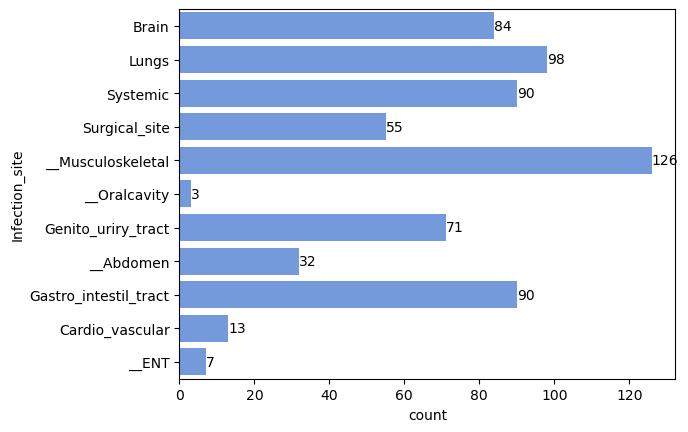

In [24]:
infection_site = pd.melt(
    data,
    id_vars= 'specimen_type',
    value_vars= ['Infection_Site_1', 'Infection_Site_2', 'Infection_Site_3'],
    value_name= 'Infection_site'
)

infection_site.dropna(subset = ['Infection_site'], inplace = True)

ax = sns.countplot(infection_site, y = 'Infection_site', color = 'cornflowerblue')
ax.bar_label(ax.containers[0], fontsize =10)

# Prior antibiotic use

In [25]:
# Get prio antibiotic use column names
prio_anti_cols = [col for col in data.columns if col.startswith('prio_antib_me_')]

# More efficient method using apply
def get_prio_antibiotic(row):
    yes_sites = [col.replace('prio_antib_me_', "").replace('___', '') for col in prio_anti_cols if row[col] == 'Yes']
    return pd.Series(yes_sites, index=[f'Prio_antib_{i+1}' for i in range(len(yes_sites))])

new_data = data.apply(get_prio_antibiotic, axis=1)
data = pd.concat([data, new_data], axis=1)

# print(data)

In [26]:
data.head()

,name_of_rrh,age,sex,hosp_48hrs,infect_site_Brain,infect_site_Lungs,infect_site_Gastro_intestil_tract,infect_site_Genito_uriry_tract,infect_site_Cardio_vascular,infect_site_Systemic,...,date_at_discharge,date_referral,length_hosp_stay,Infection_Site_1,Infection_Site_2,Infection_Site_3,Prio_antib_1,Prio_antib_2,Prio_antib_3,Prio_antib_4
0,Arua,6.0,Male,Yes,Yes,No,No,No,No,No,...,44948,NaN,12.0,Brain,NaN,NaN,NaN,NaN,NaN,NaN
1,Arua,13.0,Male,Yes,No,Yes,No,No,No,Yes,...,45082,NaN,8.0,Lungs,Systemic,NaN,NaN,NaN,NaN,NaN
2,Arua,11.0,Male,Yes,No,No,No,No,No,Yes,...,44988,NaN,14.0,Systemic,NaN,NaN,NaN,NaN,NaN,NaN
3,Arua,18.0,Male,Yes,No,No,No,No,No,No,...,44972,NaN,0.0,Surgical_site,NaN,NaN,NaN,NaN,NaN,NaN
4,Arua,17.0,Female,Yes,No,No,No,No,No,No,...,45208,NaN,10.0,Surgical_site,NaN,NaN,NaN,NaN,NaN,NaN


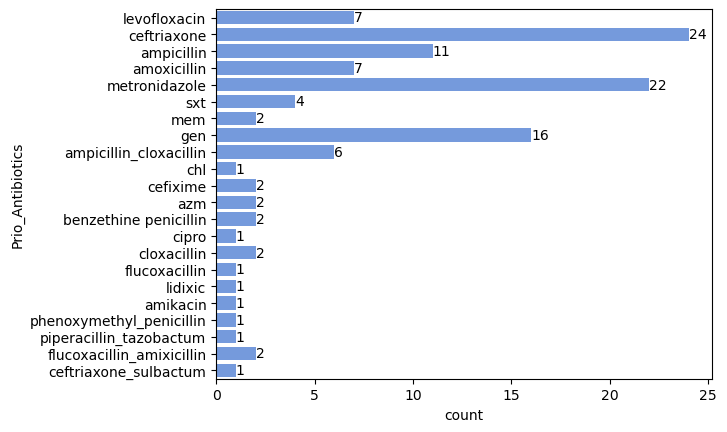

In [27]:
prio_antibiotics = pd.melt(
    data,
    id_vars = 'specimen_type',
    value_vars= ['Prio_antib_1', 'Prio_antib_2'],
    value_name= 'Prio_Antibiotics'
)

prio_antibiotics.dropna(subset = ['Prio_Antibiotics'], inplace = True)

ax = sns.countplot(prio_antibiotics, y = 'Prio_Antibiotics', color = 'cornflowerblue')
ax.bar_label(ax.containers[0], fontsize = 10)

plt.show()

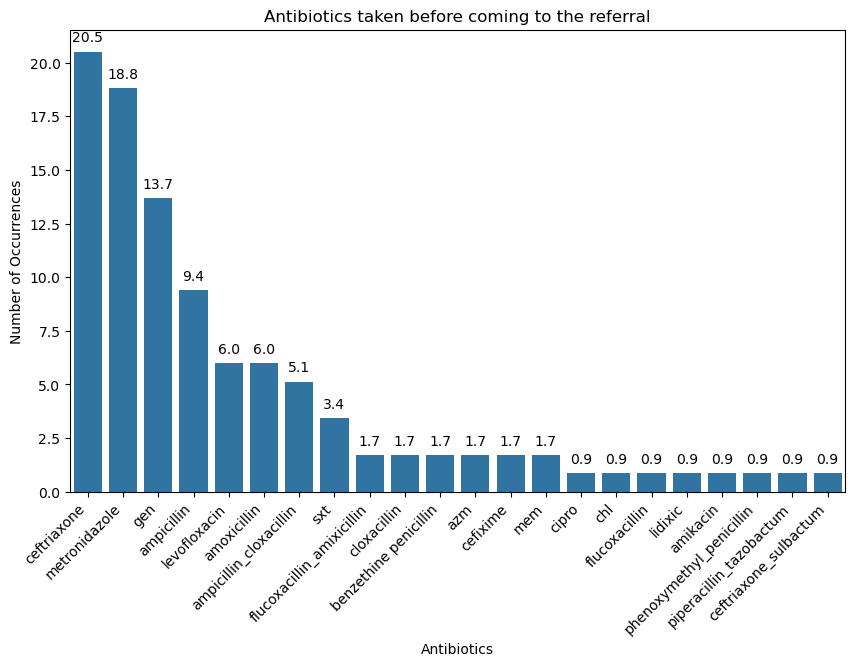

In [28]:
anti_count = prio_antibiotics['Prio_Antibiotics'].value_counts(normalize = True) * 100

plt.figure(figsize = (10,6))

ax = sns.barplot(x = anti_count.index, y = anti_count.values)
# Add labels and title
ax.set_xlabel('Antibiotics')
ax.set_ylabel('Number of Occurrences')
ax.set_title('Antibiotics taken before coming to the referral')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add count values on top of the bars with 2 decimal places
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.show()

# Antibiotics prescribed before culture

In [29]:
# Get prio antibiotic use column names
prescribed_anti_cols = [col for col in data.columns if col.startswith('antibiotics_prescribed_')]

# More efficient method using apply
def get_prescribed_antibiotic(row):
    yes_sites = [col.replace('antibiotics_prescribed_', "").replace('___', '') for col in prescribed_anti_cols if row[col] == 'Yes']
    return pd.Series(yes_sites, index=[f'Prescribed_antib_{i+1}' for i in range(len(yes_sites))])

new_data = data.apply(get_prescribed_antibiotic, axis=1)
data = pd.concat([data, new_data], axis=1)

# print(data)

In [30]:
data.head()

,name_of_rrh,age,sex,hosp_48hrs,infect_site_Brain,infect_site_Lungs,infect_site_Gastro_intestil_tract,infect_site_Genito_uriry_tract,infect_site_Cardio_vascular,infect_site_Systemic,...,Infection_Site_3,Prio_antib_1,Prio_antib_2,Prio_antib_3,Prio_antib_4,Prescribed_antib_1,Prescribed_antib_2,Prescribed_antib_3,Prescribed_antib_4,Prescribed_antib_5
0,Arua,6.0,Male,Yes,Yes,No,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,cefotaxime,NaN,NaN,NaN,NaN
1,Arua,13.0,Male,Yes,No,Yes,No,No,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arua,11.0,Male,Yes,No,No,No,No,No,Yes,...,NaN,NaN,NaN,NaN,NaN,Ceftriaxone,Gentamicin,NaN,NaN,NaN
3,Arua,18.0,Male,Yes,No,No,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,metronidazole,cefotaxime,NaN,NaN,NaN
4,Arua,17.0,Female,Yes,No,No,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,Chloramphenicol,metronidazole,levofloxacin_sulbactam,NaN,NaN


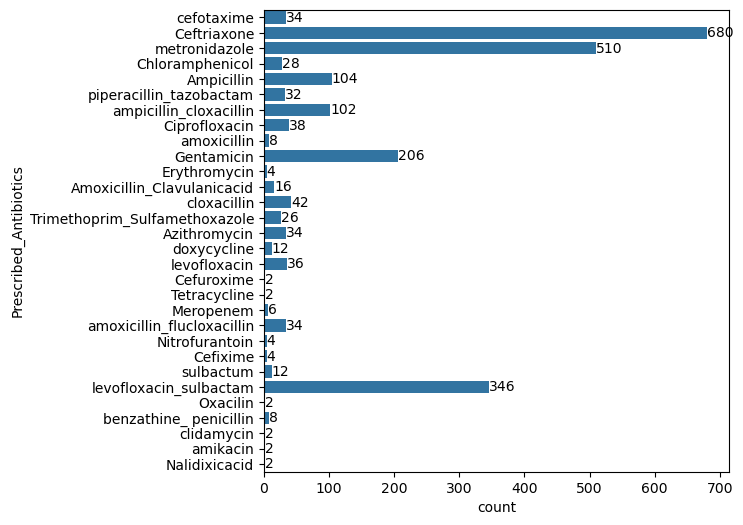

In [31]:
prescribed_anti_cols = [col for col in data.columns if col.startswith('antibiotics_prescribed_')]

# More efficient method using apply
def get_prescribed_antibiotic(row):
    yes_sites = [col.replace('antibiotics_prescribed_', "").replace('___', '') for col in prescribed_anti_cols if row[col] == 'Yes']
    return pd.Series(yes_sites, index=[f'Prescribed_antib_{i+1}' for i in range(len(yes_sites))])

new_data = data.apply(get_prescribed_antibiotic, axis=1)
data = pd.concat([data, new_data], axis=1)


prescribed_antibiotics = pd.melt(
    data,
    id_vars = 'specimen_type',
    value_vars= ['Prescribed_antib_1', 'Prescribed_antib_2', 'Prescribed_antib_3', 'Prescribed_antib_4', 'Prescribed_antib_5'],
    value_name= "Prescribed_Antibiotics"
)

prescribed_antibiotics.dropna(subset = ['Prescribed_Antibiotics'], inplace = True)

plt.figure(figsize = (6,6))

ax = sns.countplot(prescribed_antibiotics, y = 'Prescribed_Antibiotics')
ax.bar_label(ax.containers[0], fontsize = 10)

plt.show()

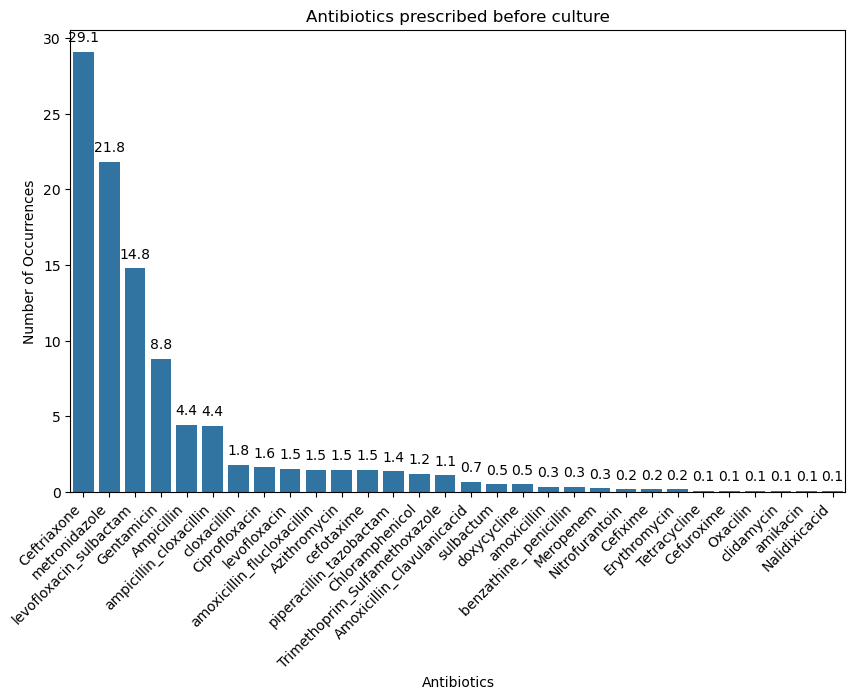

In [32]:
anti_count = prescribed_antibiotics['Prescribed_Antibiotics'].value_counts(normalize = True) * 100

plt.figure(figsize = (10,6))

ax = sns.barplot(x = anti_count.index, y = anti_count.values)
# Add labels and title
ax.set_xlabel('Antibiotics')
ax.set_ylabel('Number of Occurrences')
ax.set_title('Antibiotics prescribed before culture')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add count values on top of the bars with 2 decimal places
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.show()

# Antibiotics prescribed after culture

In [33]:
data.drop(columns = 'antib_presc_af_cul_Others', inplace = True)

# Get prio antibiotic use column names
prescribed_anti_aft_cul_cols = [col for col in data.columns if col.startswith('antib_presc_af_cul_')]

# More efficient method using apply
def get_prescribed_anti_aft_cul(row):
    yes_sites = [col.replace('antib_presc_af_cul_', "").replace('___', '') for col in prescribed_anti_aft_cul_cols if row[col] == 'Yes']
    return pd.Series(yes_sites, index=[f'Antibioitic_aft_cul_{i+1}' for i in range(len(yes_sites))])

new_data = data.apply(get_prescribed_anti_aft_cul, axis=1)
data = pd.concat([data, new_data], axis=1)

# print(data)

In [34]:
data.head()

,name_of_rrh,age,sex,hosp_48hrs,infect_site_Brain,infect_site_Lungs,infect_site_Gastro_intestil_tract,infect_site_Genito_uriry_tract,infect_site_Cardio_vascular,infect_site_Systemic,...,Prescribed_antib_3,Prescribed_antib_4,Prescribed_antib_5,Prescribed_antib_1,Prescribed_antib_2,Prescribed_antib_3,Prescribed_antib_4,Prescribed_antib_5,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2
0,Arua,6.0,Male,Yes,Yes,No,No,No,No,No,...,NaN,NaN,NaN,cefotaxime,NaN,NaN,NaN,NaN,NaN,NaN
1,Arua,13.0,Male,Yes,No,Yes,No,No,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arua,11.0,Male,Yes,No,No,No,No,No,Yes,...,NaN,NaN,NaN,Ceftriaxone,Gentamicin,NaN,NaN,NaN,NaN,NaN
3,Arua,18.0,Male,Yes,No,No,No,No,No,No,...,NaN,NaN,NaN,metronidazole,cefotaxime,NaN,NaN,NaN,NaN,NaN
4,Arua,17.0,Female,Yes,No,No,No,No,No,No,...,levofloxacin_sulbactam,NaN,NaN,Chloramphenicol,metronidazole,levofloxacin_sulbactam,NaN,NaN,Chloramphenicol,NaN


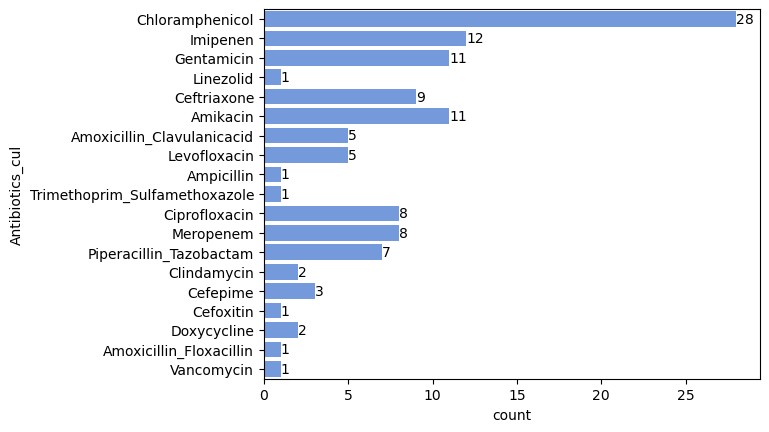

In [35]:
antib_aft_cul = pd.melt (
    data,
    id_vars= 'specimen_type',
    value_vars = ['Antibioitic_aft_cul_1', 'Antibioitic_aft_cul_2'],
    value_name = 'Antibiotics_cul'
)

# print(antib_aft_cul)
antib_aft_cul.dropna(subset= ['Antibiotics_cul'], inplace = True)

ax = sns.countplot(antib_aft_cul, y = 'Antibiotics_cul', color = 'cornflowerblue')
ax.bar_label(ax.containers[0], fontsize  = 10)

plt.show()

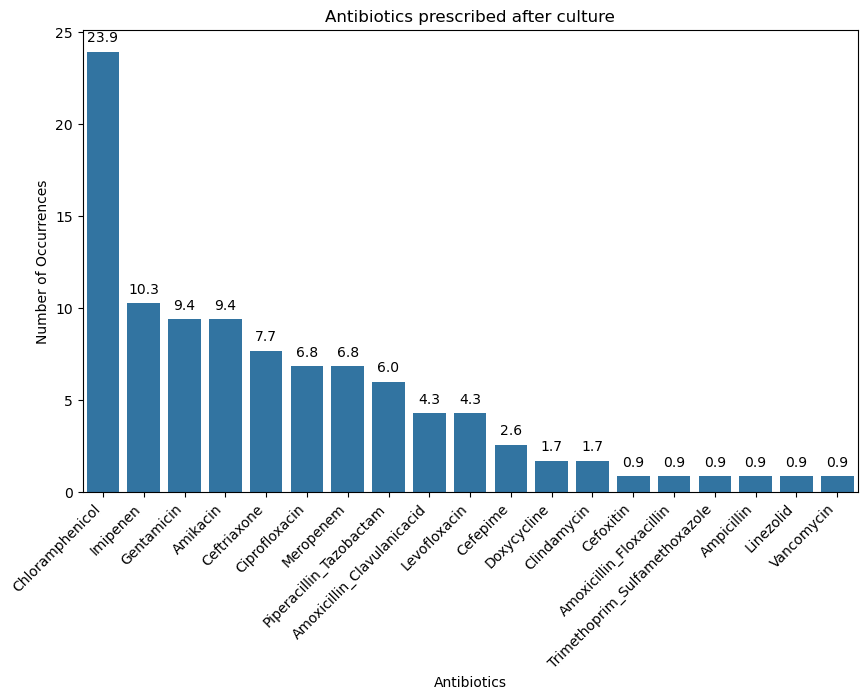

In [36]:
anti_count = antib_aft_cul['Antibiotics_cul'].value_counts(normalize = True) * 100

plt.figure(figsize = (10,6))

ax = sns.barplot(x = anti_count.index, y = anti_count.values)
# Add labels and title
ax.set_xlabel('Antibiotics')
ax.set_ylabel('Number of Occurrences')
ax.set_title('Antibiotics prescribed after culture')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add count values on top of the bars with 2 decimal places
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.show()

# Comorbidities

In [38]:
#data.drop(columns = 'antib_presc_af_cul_Others', inplace = True)

# Get prio antibiotic use column names
comobidity = [col for col in data.columns if col.startswith('cormobidities_')]

# More efficient method using apply
def get_comobidity(row):
    yes_sites = [col.replace('cormobidities_', "").replace('___', '') for col in comobidity if row[col] == 'Yes']
    return pd.Series(yes_sites, index=[f'Comobidity{i+1}' for i in range(len(yes_sites))])

new_data = data.apply(get_comobidity, axis=1)
data = pd.concat([data, new_data],
                  axis=1)

data.head()

,name_of_rrh,age,sex,hosp_48hrs,infect_site_Brain,infect_site_Lungs,infect_site_Gastro_intestil_tract,infect_site_Genito_uriry_tract,infect_site_Cardio_vascular,infect_site_Systemic,...,Prescribed_antib_1,Prescribed_antib_2,Prescribed_antib_3,Prescribed_antib_4,Prescribed_antib_5,Antibioitic_aft_cul_1,Antibioitic_aft_cul_2,Comobidity1,Comobidity2,Comobidity3
0,Arua,6.0,Male,Yes,Yes,No,No,No,No,No,...,cefotaxime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arua,13.0,Male,Yes,No,Yes,No,No,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arua,11.0,Male,Yes,No,No,No,No,No,Yes,...,Ceftriaxone,Gentamicin,NaN,NaN,NaN,NaN,NaN,sickle_cell,NaN,NaN
3,Arua,18.0,Male,Yes,No,No,No,No,No,No,...,metronidazole,cefotaxime,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arua,17.0,Female,Yes,No,No,No,No,No,No,...,Chloramphenicol,metronidazole,levofloxacin_sulbactam,NaN,NaN,Chloramphenicol,NaN,hiv,NaN,NaN


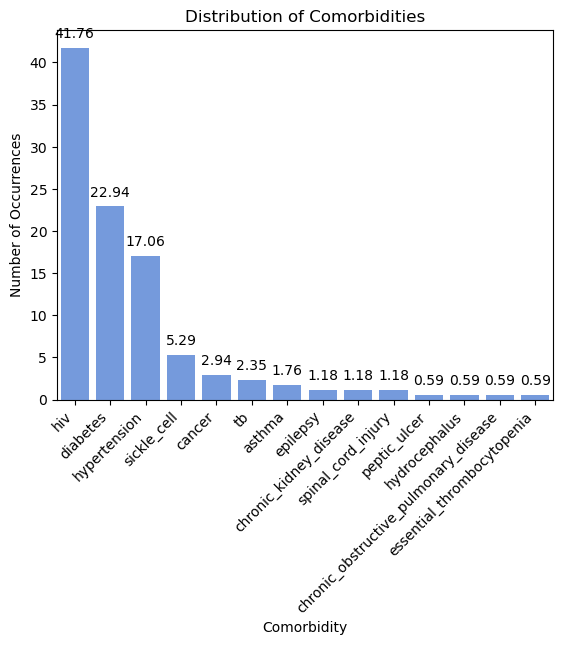

In [39]:
como = pd.melt(
    data,
    id_vars= 'specimen_type',
    value_vars= ['Comobidity1', 'Comobidity2', 'Comobidity3'],
    value_name= 'Comobidity'
)

como.dropna(subset = ['Comobidity'], inplace = True)

como_count = como['Comobidity'].value_counts(normalize= True) * 100

ax = sns.barplot(x = como_count.index, y = como_count.values, color = 'cornflowerblue')

# Add labels and title
ax.set_xlabel('Comorbidity')
ax.set_ylabel('Number of Occurrences')
ax.set_title('Distribution of Comorbidities')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add count values on top of the bars with 2 decimal places
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.show()

In [40]:
data.to_csv("Final ML Clinical data 14.02.25.csv")

# Data analysis

In [42]:
data = pd.read_excel("/home/racheal/ACE/camonet/ML/ML clinical outcomes data 14.02.25.xlsx")

In [43]:
data.describe()

,age,organism_isolated,length_hosp_stay
count,598.000000,324.000000,596.000000
mean,30.272575,1.203704,22.578859
std,22.906648,0.432988,39.681067
min,0.000000,1.000000,0.000000
25%,12.000000,1.000000,6.000000
50%,28.000000,1.000000,14.000000
75%,44.000000,1.000000,27.000000
max,95.000000,3.000000,744.000000


In [45]:
data.shape

(599, 40)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Pediatric ward'),
  Text(1, 0, 'Medical ward'),
  Text(2, 0, 'Surgical ward'),
  Text(3, 0, 'Maternity ward'),
  Text(4, 0, 'Gyecology ward'),
  Text(5, 0, 'Orthopedic ward'),
  Text(6, 0, 'ICU Unit'),
  Text(7, 0, 'NICU'),
  Text(8, 0, 'Private wing'),
  Text(9, 0, 'HDU'),
  Text(10, 0, 'Urology ward')])

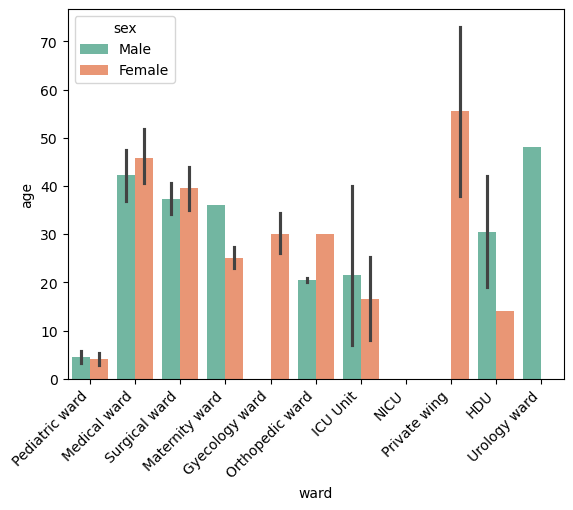

In [9]:
sns.barplot(data, x = 'ward', y = 'age', hue = 'sex', palette='Set2')

plt.xticks(rotation = 45, ha = 'right')

([0, 1, 2, 3, 4],
 [Text(0, 0, '< 1 week'),
  Text(1, 0, '1- < 2 weeks'),
  Text(2, 0, 'Unknown'),
  Text(3, 0, '2-4 weeks'),
  Text(4, 0, '>4 weeks')])

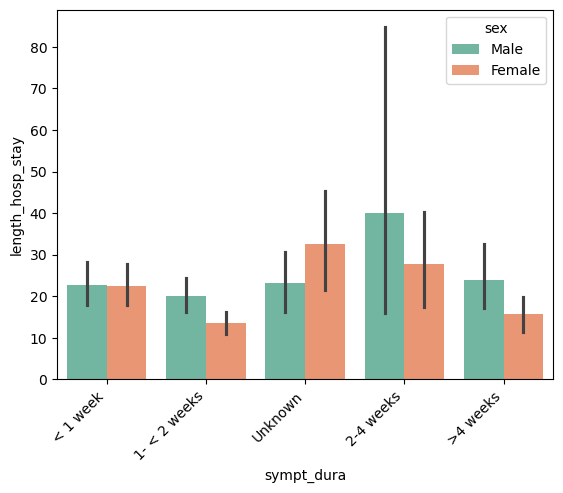

In [12]:
sns.barplot(data, x = 'sympt_dura', y = 'length_hosp_stay', hue = 'sex', palette='Set2')

plt.xticks(rotation = 45, ha = 'right')

In [18]:
data['intubated'] = data['intubated'].replace({'Unknown': 'No'})

([0, 1], [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

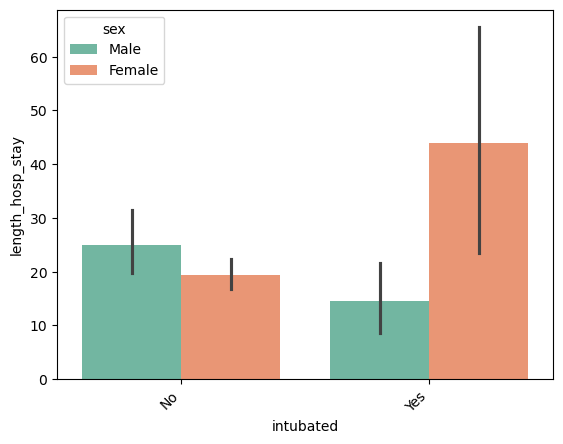

In [19]:
sns.barplot(data, x = 'intubated', y = 'length_hosp_stay', hue = 'sex', palette='Set2')

plt.xticks(rotation = 45, ha = 'right')

/tmp/ipykernel_4340/1877101178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=site_counts.index, y=site_counts.values, palette="Set2")


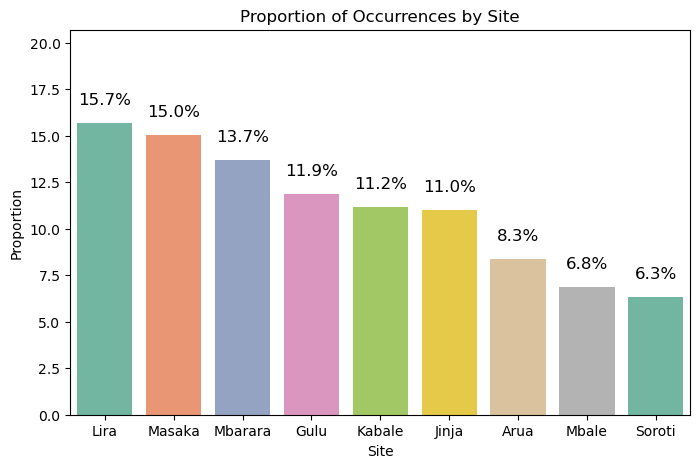

In [12]:
# Calculate proportions
site_counts = data['name_of_rrh'].value_counts(normalize=True) *100 # This gives proportions

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=site_counts.index, y=site_counts.values, palette="Set2")

# Labels
plt.xlabel("Site")
plt.ylabel("Proportion")
plt.title("Proportion of Occurrences by Site")

# Show percentage values on bars
for i, val in enumerate(site_counts.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=12)

plt.ylim(0, max(site_counts.values) + 5) 
plt.show()

/tmp/ipykernel_5104/1122585324.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=site_counts.index, y=site_counts.values, palette="Set2")


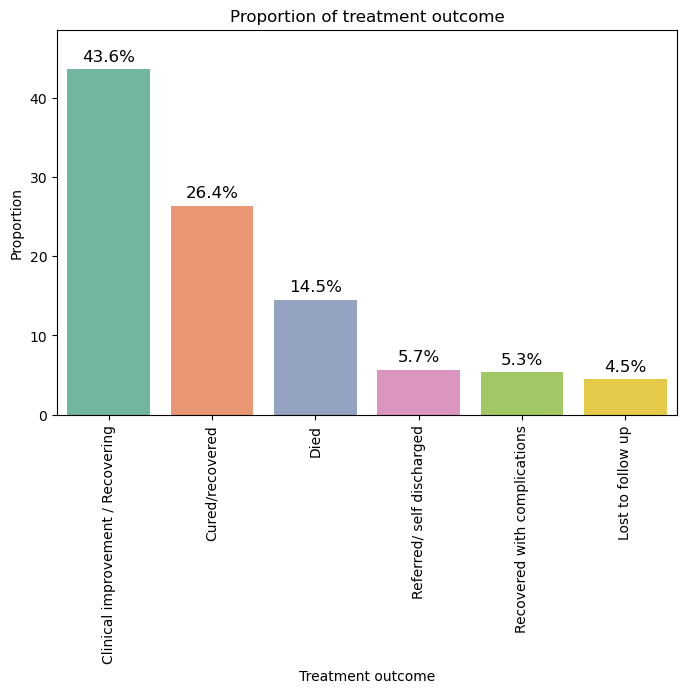

In [4]:
# Calculate proportions
site_counts = data['treatment_outcome'].value_counts(normalize=True) *100 # This gives proportions

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=site_counts.index, y=site_counts.values, palette="Set2")

# Labels
plt.xlabel("Treatment outcome")
plt.ylabel("Proportion")
plt.title("Proportion of treatment outcome")

# Show percentage values on bars
for i, val in enumerate(site_counts.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=12)

plt.ylim(0, max(site_counts.values) + 5) 
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Calculate proportions
site_counts = data['treatment_outcome'].value_counts(normalize=True) *100 # This gives proportions

# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='treatment_outcome', data, y='length_hosp_stay', palette="Set2")

# Labels
plt.xlabel("Treatment outcome")
plt.ylabel("Proportion")
plt.title("Proportion of treatment outcome")

# Show percentage values on bars
for i, val in enumerate(site_counts.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=12)

plt.ylim(0, max(site_counts.values) + 5) 
plt.xticks(rotation = 90)
plt.show()

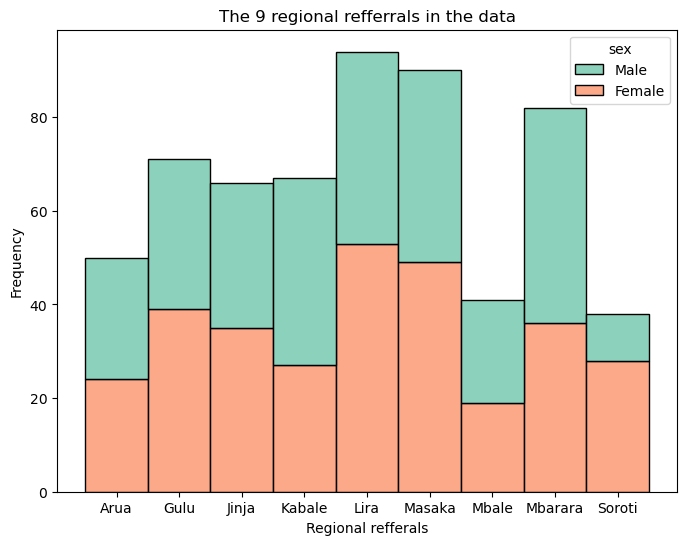

In [15]:
plt.figure(figsize=(8 , 6))

sns.histplot(data, x =  "name_of_rrh", hue = 'sex', stat="count", palette= "Set2", multiple = 'stack')
#ax.bar_label(ax.containers[0], fontsize = 10)

plt.title("The 9 regional refferrals in the data")
plt.xlabel("Regional refferals")
plt.ylabel("Frequency")
plt.show()

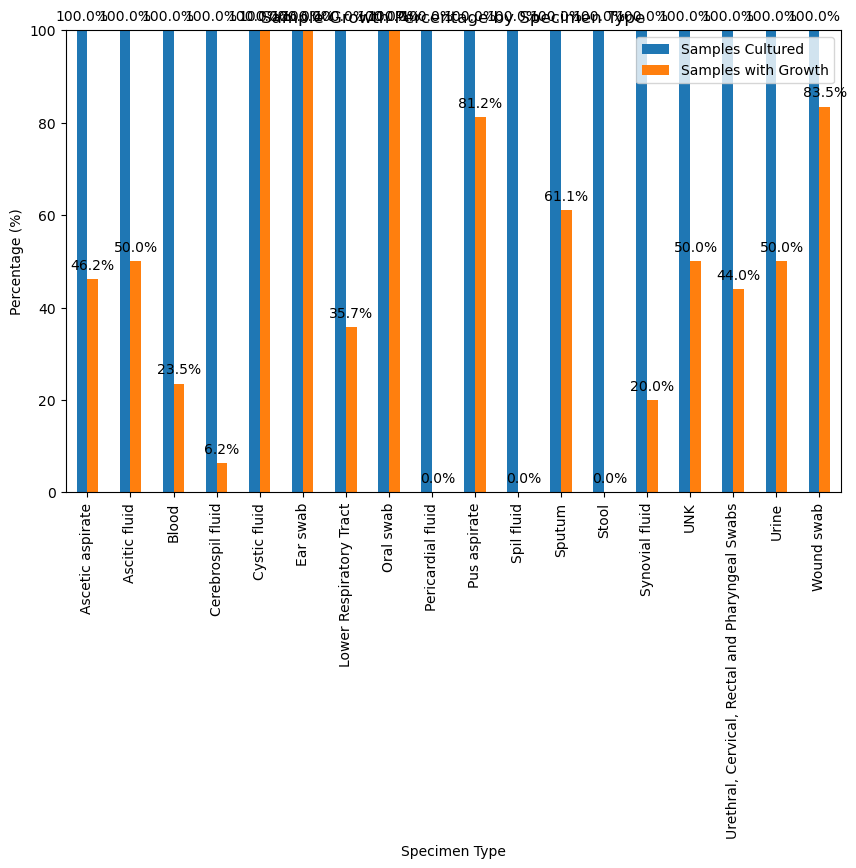

In [19]:
# Grouped data
total_samples = data.groupby('specimen_type').size()
growth_counts = data[data['growth1'] == 'Yes'].groupby('specimen_type').size()

# Create DataFrame
df_counts = pd.DataFrame({'Samples Cultured': total_samples, 
                          'Samples with Growth': growth_counts})

# Convert to percentages
df_percentages = df_counts.div(df_counts['Samples Cultured'], axis=0) * 100

# Plot
ax = df_percentages.plot(kind='bar', figsize=(10, 6))

# Labels and title
plt.xlabel('Specimen Type')
plt.ylabel('Percentage (%)')
plt.title('Sample Growth Percentage by Specimen Type')

# Add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.ylim(0, 100)  # Since it's percentages
plt.legend()
plt.show()
